In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [7]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)
# generator_llm = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0.8
# )

evaluator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

optimizer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

In [22]:
from pydantic import BaseModel, Field

class ResumeEvaluation(BaseModel):
    score: int = Field(description="Resume score out of 10")
    feedback: str = Field(description="Feedback for improvement")

In [23]:
structured_evaluator_llm = evaluator_llm.with_structured_output(ResumeEvaluation)

In [ ]:
class ResumeState(TypedDict):
    # role: str 
    resume: str
    score: int 
    feedback: str

    iteration: int 
    max_iteration: int

In [24]:
def evaluate_resume(state: ResumeState):

    prompt = f"""
    Evaluate the following resume:

    {state["resume"]}

    Give:
    1. Score out of 10
    2. Feedback
    """

    response = structured_evaluator_llm.invoke(prompt)

    return {
        "score": response.score,
        "feedback": response.feedback
    }

def route_resume(state):

    if (state["score"] >= 8 or state["iteration"] >= state["max_iteration"]):
        return "approved"
    return "improve"
    
def high_quality_resume(state: ResumeState):

    result =  f'your resume is high quality resume \n No Need To Improve It'

    return {'result': result}

def improve_resume(state: ResumeState):
    prompt = f""" improve the resume based on 
            Feedback:
            {state["feedback"]}

            Resume:
            {state['resume']}"""
    
    improved = optimizer_llm.invoke(prompt).content

    return {"resume": improved,
            "iteration": state['iteration'] + 1}

In [25]:
graph = StateGraph(ResumeState)

graph.add_node('evaluate_resume', evaluate_resume)
graph.add_node('improve_resume', improve_resume)

graph.add_edge(START, 'evaluate_resume')
graph.add_conditional_edges("evaluate_resume", route_resume, {"approved": END, "improve": "improve_resume"})
graph.add_edge("improve_resume", "evaluate_resume")

workflow = graph.compile()


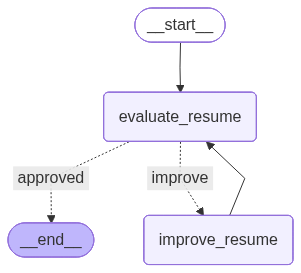

In [26]:
workflow

In [27]:
initial_state = {
    'resume' : "I am currently pursuing a B.Tech in Computer Engineering at MPSTME, NMIMS University (2024–2027) with a CGPA of 2.96, after completing my Diploma in Computer Engineering from K.K. Wagh Polytechnic under MSBTE with 84.5%, and my secondary education from New English School Kanisht Mahavidyalay with 87.9%. I have worked on several projects, including a Sign Language Recognizer for Deaf People, where I developed a real-time accessibility tool using Python and OpenCV to translate hand gestures into text, implementing advanced contour detection, image preprocessing techniques, and machine learning models to improve recognition accuracy and reduce false positives by 15%. I also developed an Indian Livestock Breed Classifier, an AI-driven system for identifying cattle and buffalo breeds using image processing techniques such as Discrete Cosine Transform (DCT), Histogram Equalization, morphological operations, and region-growing segmentation to enhance classification accuracy. Additionally, I completed an Industrial Training and Internship in Web Application Development (Java) at R3 Systems from June 2023 to July 2023, where I gained hands-on experience with Core Java, Servlets, JSP, JDBC, object-oriented programming, database connectivity, debugging, and full-stack web application development. My academic and professional development is further supported by participation in a Web Programming Workshop hosted by IIT, focusing on scalable web architecture and responsive design, and by authoring a literature review titled “A Review of Edge Computing and the Evolution of Modern Operating Systems,” which analyzed over 80 scholarly sources to examine the transition from cloud-centric to decentralized edge computing architectures. My technical skills include Java, Python, OpenCV, Pandas, FastAPI, Django, Android Studio, Framer, Figma, and Git/GitHub, while my strengths include project ownership, critical thinking, technical communication, and documentation."
}

workflow.invoke(initial_state)

{'resume': 'I am currently pursuing a B.Tech in Computer Engineering at MPSTME, NMIMS University (2024–2027) with a CGPA of 2.96, after completing my Diploma in Computer Engineering from K.K. Wagh Polytechnic under MSBTE with 84.5%, and my secondary education from New English School Kanisht Mahavidyalay with 87.9%. I have worked on several projects, including a Sign Language Recognizer for Deaf People, where I developed a real-time accessibility tool using Python and OpenCV to translate hand gestures into text, implementing advanced contour detection, image preprocessing techniques, and machine learning models to improve recognition accuracy and reduce false positives by 15%. I also developed an Indian Livestock Breed Classifier, an AI-driven system for identifying cattle and buffalo breeds using image processing techniques such as Discrete Cosine Transform (DCT), Histogram Equalization, morphological operations, and region-growing segmentation to enhance classification accuracy. Addit